# Explore here

In [29]:
import pandas as pd

df = pd.read_csv("../data/raw/screen_time_mental_health (1).csv")

print(df.head())

   subject_id   sex  screen_time_index  est_leisure_screen_hours  \
0           1   Boy              3.333                      4.64   
1           2  Girl              3.333                      4.07   
2           3   Boy              3.333                      4.07   
3           4   Boy              4.333                      6.07   
4           5   Boy              1.667                      0.50   

   sleep_quality_index  avg_sleep_hours  midsleep_weekend_hours  \
0                 2.25             8.36                    4.58   
1                 2.50             7.31                    5.42   
2                 2.00             8.75                    5.50   
3                 1.50             8.17                    6.62   
4                 2.50             8.88                    4.12   

   social_jetlag_hours  bdi_total  depressed  
0                 1.92          6          0  
1                 2.25          7          0  
2                 2.62         27          1  


In [30]:
df.shape

(4810, 10)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   subject_id                4810 non-null   int64  
 1   sex                       4810 non-null   str    
 2   screen_time_index         4810 non-null   float64
 3   est_leisure_screen_hours  4810 non-null   float64
 4   sleep_quality_index       4810 non-null   float64
 5   avg_sleep_hours           4810 non-null   float64
 6   midsleep_weekend_hours    4810 non-null   float64
 7   social_jetlag_hours       4810 non-null   float64
 8   bdi_total                 4810 non-null   int64  
 9   depressed                 4810 non-null   int64  
dtypes: float64(6), int64(3), str(1)
memory usage: 375.9 KB


Nuestro dataframe tiene 4810 observaciones y 10 variables. Para el modelo de regresión, vamos a tomar como variable dependiente 'bdi_total' y como predictoras todas las restantes a excepción de dos: 'subject_id', que no debería utilizarse como predictor porque es simplemente un identificador, y 'depressed', que tampoco conviene incluirlo si es una variable construida a partir de 'bdi_total', porque produciría fuga de información. Todas nuestras variables son todas numéricas menos una: 'sex', que es categórica. Por otro lado podemos ver que no hay valores nulos, y que el número de filas es de 4810, que corresponden al número de niños de entre 12 y 16 años consultados.

In [32]:
df = df.drop(columns=["subject_id", "depressed"])

In [33]:
df.duplicated().sum()

np.int64(0)

Podemos corroborar que no hay duplicados. 

Las Variables significan:


subject_id: Identificador único de cada participante


sex:	Sexo de la persona participante	


screen_time_index:	Índice que resume el nivel de exposición/uso de pantallas


est_leisure_screen_hours:	Horas estimadas de uso de pantallas durante el tiempo libre


sleep_quality_index:	Índice que representa la calidad del sueño


avg_sleep_hours:	Promedio de horas de sueño


midsleep_weekend_hours:	Hora media del sueño durante los fines de semana


social_jetlag_hours:	Diferencia entre los horarios de sueño de días laborales y fines de semana


bdi_total: Puntaje total de síntomas depresivos según el BDI


depressed:	Indicador de si la persona supera un determinado umbral de síntomas depresivos

## Análisis descriptivo

In [34]:
df.describe()

,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total
count,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000
mean,3.219097,3.958299,1.901611,7.689067,5.570553,2.400200,7.271518
std,1.026348,2.387289,0.851176,1.270213,1.415505,1.137931,7.703156
min,1.000000,0.500000,1.000000,1.360000,1.670000,-3.030000,0.000000
25%,2.333000,2.070000,1.250000,7.050000,4.540000,1.580000,2.000000
50%,3.000000,3.500000,1.750000,7.870000,5.420000,2.290000,5.000000
75%,4.000000,5.500000,2.250000,8.540000,6.500000,3.120000,10.000000
max,6.000000,10.000000,6.000000,12.210000,10.500000,6.960000,51.000000


- 'screen_time_index': La media es ligeramente superior a la mediana, lo que sugiere una leve asimetría positiva. El 50% central de los participantes se encuentra entre 2,33 y 4,00. (la Media es de 3,22, la Mediana de 3,00, el Min: 1 y el Máx: 6). La desviación estándar de 1,03 indica una dispersión moderada respecto de la media. Al estar limitada entre 1 y 6, probablemente se trate de una variable discreta/ordinal, por lo que no se espera necesariamente una distribución normal.


- 'est_leisure_screen_hours': En este caso hay una diferencia más importante entre media y mediana: 3,96 > 3,50, y esto sugiere asimetría positiva. Además, el máximo de 10 horas está bastante alejado del Q3 de 5,50, por lo que probablemente exista una cola hacia valores altos y posiblemente algunos valores atípicos.
El rango intercuartílico es: 5,50 − 2,07 = 3,43 horas
Por lo tanto, existe una variabilidad considerable en el tiempo de pantalla durante el ocio.

En conclusión, 'est_leisure_screen_hours' presenta una distribución probablemente asimétrica hacia la derecha, debido a que la media supera a la mediana y existen valores elevados alejados del centro de la distribución. La variable presenta una dispersión considerable.


- 'sleep_quality_index': En este caso también la Media supera a la Mediana, por lo que podemos sospechar asimetría positiva. El 75% de los datos está por debajo de 2,25, mientras que el máximo alcanza 6. Esto sugiere posible cola derecha bastante marcada. Por lo tanto esta variable presenta una distribución concentrada en valores bajos, con una posible asimetría positiva causada por la presencia de valores elevados. La diferencia entre el tercer cuartil y el máximo sugiere posibles valores atípicos.


- 'avg_sleep_hours': En esta variable ocurre lo contrario, la Media es menor que la Mediana. Esto puede indicar una ligera asimetrá negativa, sin embargo ambas son relativamente cercanas por lo que la distribución podría ser aproximadamente simétrica, aunque con algunos valores bajos que arrastran la media hacia abajo.

El 50% central se encuentra entre 7,05 y 8,54 horas, lo que indica que la mayoría de los participantes presenta valores de sueño relativamente concentrados, es decir que presenta una distribución relativamente concentrada alrededor de 7–8 horas diarias. La proximidad entre la media y la mediana sugiere una distribución aproximadamente simétrica, aunque la presencia de valores muy bajos podría generar una ligera asimetría negativa.


- 'midsleep_weekend_hours': La media es ligeramente superior a la mediana (5,57 > 5,42) Esto sugiere una ligera asimetría positiva.
El 50% central está entre 4,54 y 6,50 horas. El máximo de 10,50 está bastante por encima del tercer cuartil, por lo que sería conveniente verificar gráficamente si existen valores atípicos. Esta variable de 'Hora media del sueño durante los fines de semana' presenta una distribución relativamente concentrada, con una ligera asimetría positiva y posibles valores extremos altos.


- 'social_jetlag_hours': La media vuelve a ser ligeramente superior a la mediana (2,40 > 2,29), esto apunta a una ligera asimetría positiva. Hay además un dato interesante: el mínimo es −3,03 horas. Esto no necesariamente significa un error: depende de cómo haya sido definida y calculada la variable. Un valor negativo puede representar que el horario de sueño del fin de semana está adelantado respecto al horario de referencia. El 50% de las observaciones está entre 1,58 y 3,12 horas.

En conclusión, esta variable presenta una distribución relativamente concentrada alrededor de 2–3 horas, con una ligera asimetría positiva y presencia de valores negativos y positivos.


- 'bdi_total': Esta variable (objetivo) presenta una distribución marcadamente asimétrica hacia la derecha. La media (7,27) es superior a la mediana (5), mientras que el máximo alcanza 51 puntos frente a un tercer cuartil de 10. Esto indica la presencia de participantes con niveles de síntomas depresivos considerablemente superiores al resto y deberá ser tenido en cuenta al construir el modelo de regresión.El máximo de 51 está muy alejado del tercer cuartil (10). Esto es una señal bastante clara de que bdi_total probablemente tenga una distribución asimétrica positiva, con una cola derecha larga y valores atípicos altos.

- 'sex': La variable sex presenta una distribución prácticamente equilibrada entre ambas categorías. Los participantes identificados como Boys representan el 50,85%, mientras que Girls representan el 49,15%. Por lo tanto, no se observa un desequilibrio importante entre los grupos.



In [35]:
predictoras = [
    "screen_time_index",
    "est_leisure_screen_hours",
    "sleep_quality_index",
    "avg_sleep_hours",
    "midsleep_weekend_hours",
    "social_jetlag_hours"
]

estadisticas = pd.DataFrame({
    "Media": df[predictoras].mean(),
    "Mediana": df[predictoras].median(),
    "Moda": df[predictoras].mode().iloc[0],
    "Desv. estándar": df[predictoras].std(),
    "Varianza": df[predictoras].var(),
    "Mínimo": df[predictoras].min(),
    "Q1": df[predictoras].quantile(0.25),
    "Q3": df[predictoras].quantile(0.75),
    "Máximo": df[predictoras].max(),
    "Asimetría": df[predictoras].skew(),
    "Curtosis": df[predictoras].kurt()
})

estadisticas.round(3)

,Media,Mediana,Moda,Desv. estándar,Varianza,Mínimo,Q1,Q3,Máximo,Asimetría,Curtosis
screen_time_index,3.219,3.00,2.333,1.026,1.053,1.00,2.333,4.00,6.00,0.505,-0.404
est_leisure_screen_hours,3.958,3.50,2.070,2.387,5.699,0.50,2.070,5.50,10.00,0.872,0.094
sleep_quality_index,1.902,1.75,1.250,0.851,0.725,1.00,1.250,2.25,6.00,1.470,2.537
avg_sleep_hours,7.689,7.87,8.430,1.270,1.613,1.36,7.050,8.54,12.21,-0.922,1.525
midsleep_weekend_hours,5.571,5.42,5.250,1.416,2.004,1.67,4.540,6.50,10.50,0.436,0.015
social_jetlag_hours,2.400,2.29,2.000,1.138,1.295,-3.03,1.580,3.12,6.96,0.382,0.412


Acá agregamos la Moda, las medidas de dispersión (varianza y desviación estándar) y las medidas de formas (Curtosis y Asimetría) de cada una de las variables predictoras para enriquecer nuestro análisis.

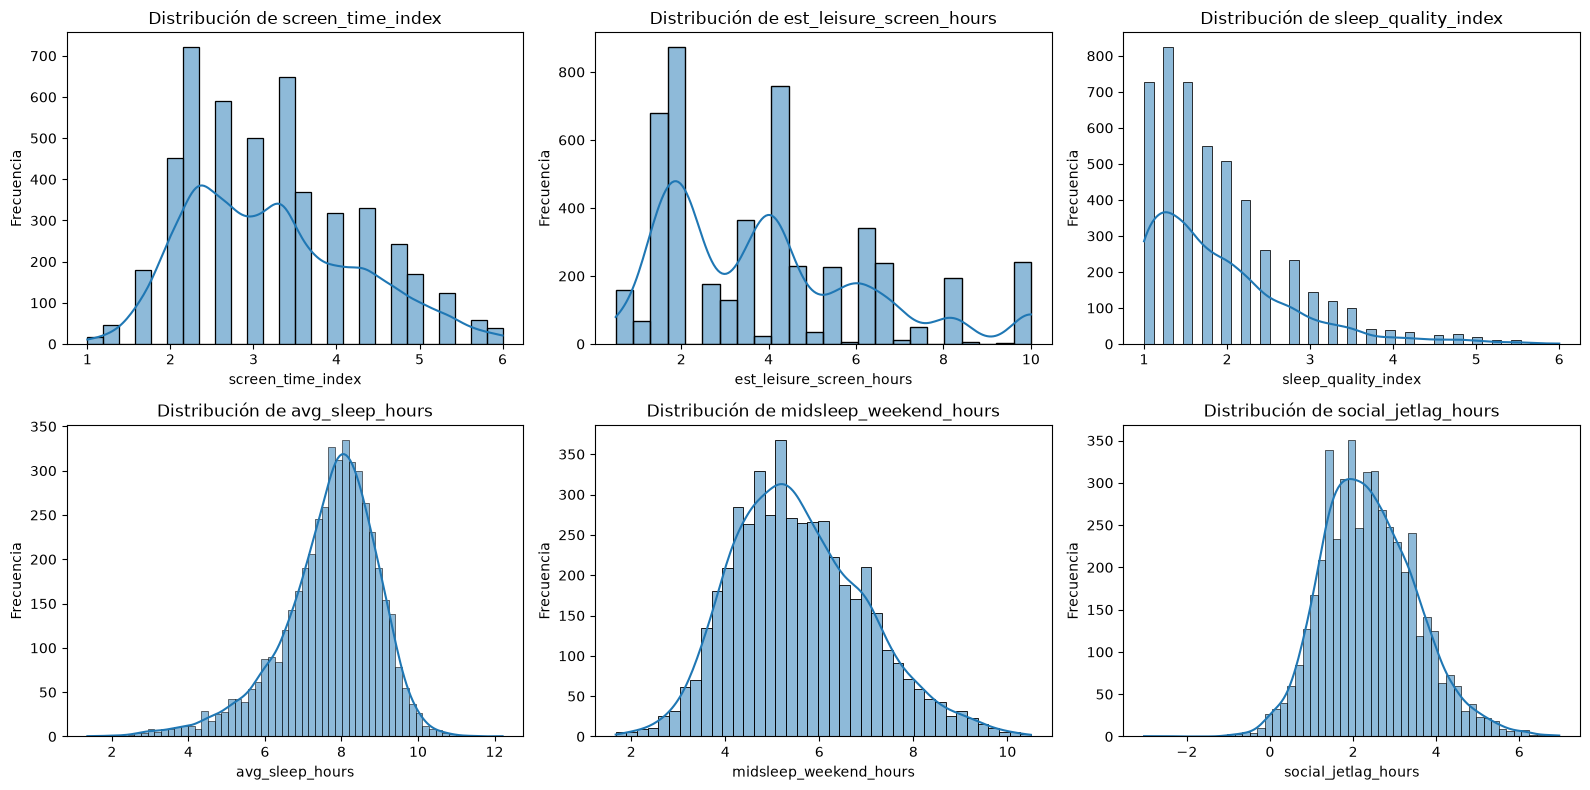

In [36]:
# Vamos a graficar los Histogramas

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, variable in zip(axes.flatten(), predictoras):

    sns.histplot(
        data=df,
        x=variable,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribución de {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

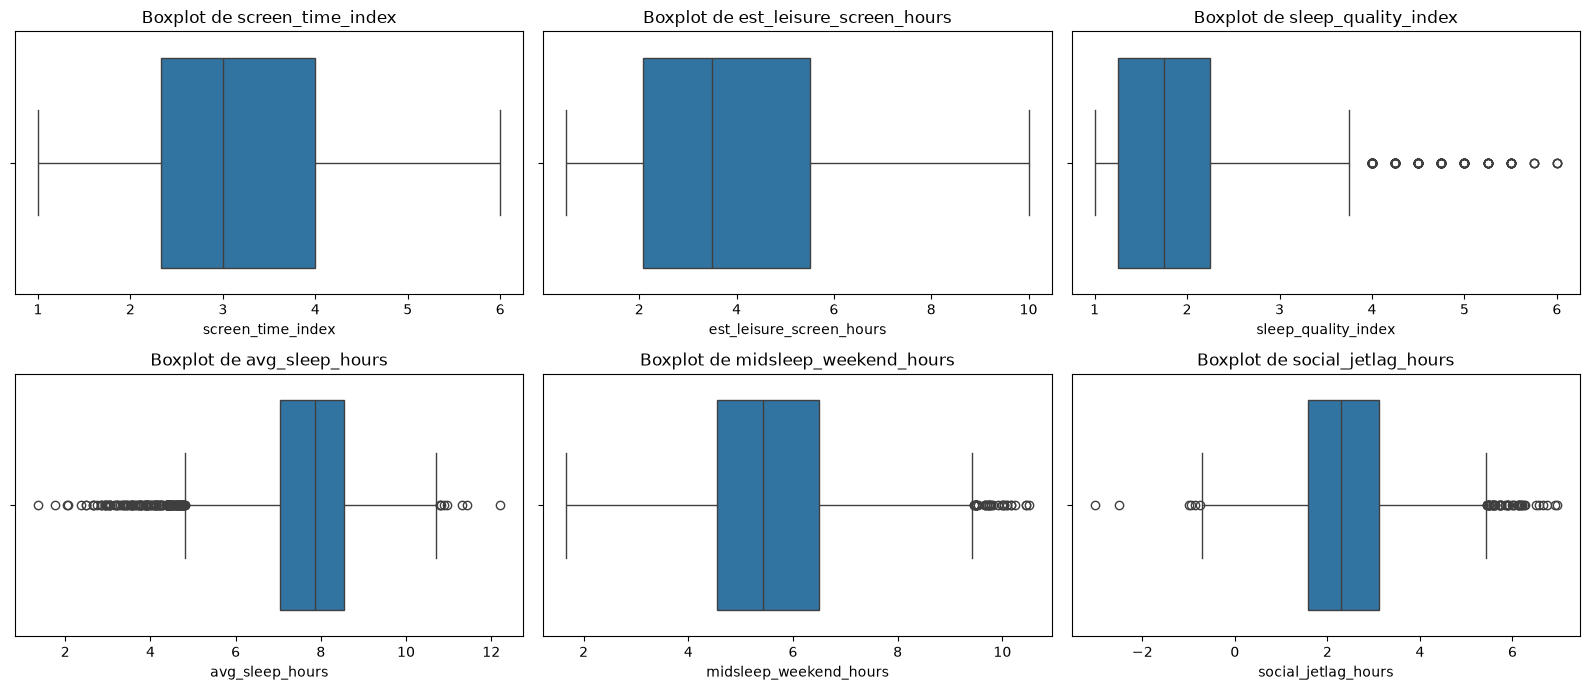

In [37]:
# BOXPLOTS

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

for ax, variable in zip(axes.flatten(), predictoras):

    sns.boxplot(
        data=df,
        x=variable,
        ax=ax
    )

    ax.set_title(f"Boxplot de {variable}")
    ax.set_xlabel(variable)

plt.tight_layout()
plt.show()

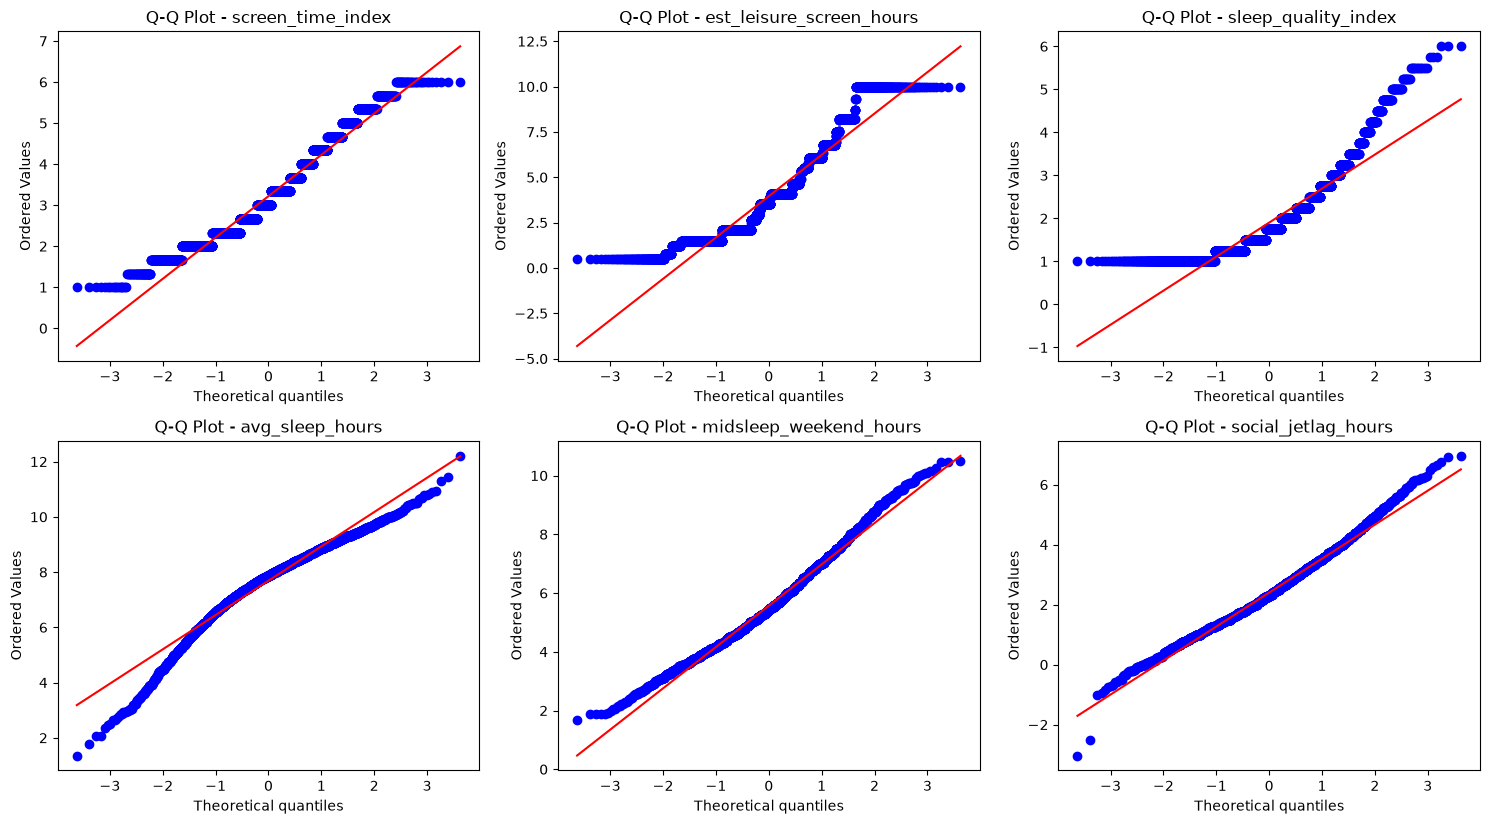

In [38]:
# Q-Q plots

import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, variable in zip(axes.flatten(), predictoras):

    stats.probplot(
        df[variable].dropna(),
        dist="norm",
        plot=ax
    )

    ax.set_title(f"Q-Q Plot - {variable}")

# Ocultar los espacios que sobren
for ax in axes.flatten()[len(predictoras):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Y la variable 'sex' que es categórica/binaria, por lo que la vamos a analizar con: Frecuencia absoluta, Porcentaje, Moda y Gráfico de barras.

In [39]:
# Frecuencias
print(df["sex"].value_counts())

# Porcentajes
print(df["sex"].value_counts(normalize=True) * 100)

# Moda
print("Moda:", df["sex"].mode()[0])

sex
Boy     2446
Girl    2364
Name: count, dtype: int64
sex
Boy     50.852391
Girl    49.147609
Name: proportion, dtype: float64
Moda: Boy


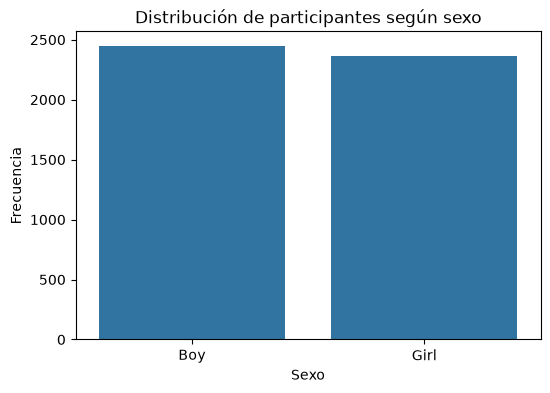

In [40]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="sex"
)

plt.title("Distribución de participantes según sexo")
plt.xlabel("Sexo")
plt.ylabel("Frecuencia")

plt.show()

En este caso ya sabemos que:

Boy: 2446 → 50,85%
Girl: 2364 → 49,15%

Por lo tanto, la distribución está muy equilibrada.

¿Podemos estimar el puntaje de síntomas depresivos de una persona utilizando sus hábitos de sueño y uso de pantallas? En este caso, regresión es la elección de modelo que hacemos.


**Objetivo: desarrollar un modelo de Machine Learning capaz de predecir el puntaje bdi_total de un individuo utilizando variables relacionadas con el uso de pantallas, el sueño y otras características disponibles en el dataset.**

Tipo de aprendizaje: supervisado.

Tipo de problema: regresión.

Variable objetivo (y): bdi_total

**La regresión es una elección adecuada porque nuestra variable objetivo es numérica y continua. Posteriormente debemos comprobar mediante análisis exploratorio si una regresión lineal es apropiada o si sería conveniente utilizar otro modelo de regresión.**

BDI significa Beck Depression Inventory, un instrumento utilizado para evaluar la presencia/intensidad de síntomas depresivos. y por lo tanto, 'bdi_total' representa el puntaje total obtenido por la persona. Con la regresión lineal, el modelo intentará encontrar una relación matemática entre las variables.

No utilizaremos 'subject_id', la eliminaremos de nuestro análisis por irrelevante, ya que es un identificador de cada participante sin importancia para el analisis predictivo.

Y, en principio, tampoco: 'depressed', porque es una variable derivada del nivel de depresión y podría introducir data leakage dependiendo de cómo haya sido construida.

## Análisis de variables univariante

In [41]:
df["sex"].value_counts()

sex
Boy     2446
Girl    2364
Name: count, dtype: int64

In [42]:
df["sex"] = df["sex"].map({
    "Boy": 0,
    "Girl": 1
})

Tenemos que convertir nuestra variable categórica en numérica, porque un modelo de Regresión Lineal necesita trabajar valores numéricos. Como 'sex' tiene sólo dos categorías, la convertimos en una variable binaria. 

In [43]:
print(df["sex"].value_counts())

sex
0    2446
1    2364
Name: count, dtype: int64


Podemos ver que casi la mitad de las filas corresponden a encuestados de sexo masculino y el otro 50 a femenino. Hay un poco más de hombres encuestados, pero valores equilibrados de cada sexo. 

### Análisis sobre variables numéricas

Normalmente se representan utilizando un histograma y diagramas de caja, expuestos juntos. En nuestro Dataset todas las variables son numéricas, ya que a la única categórica ('sex') la transformamos y quedó categórica numérica (Girl/Boy). 

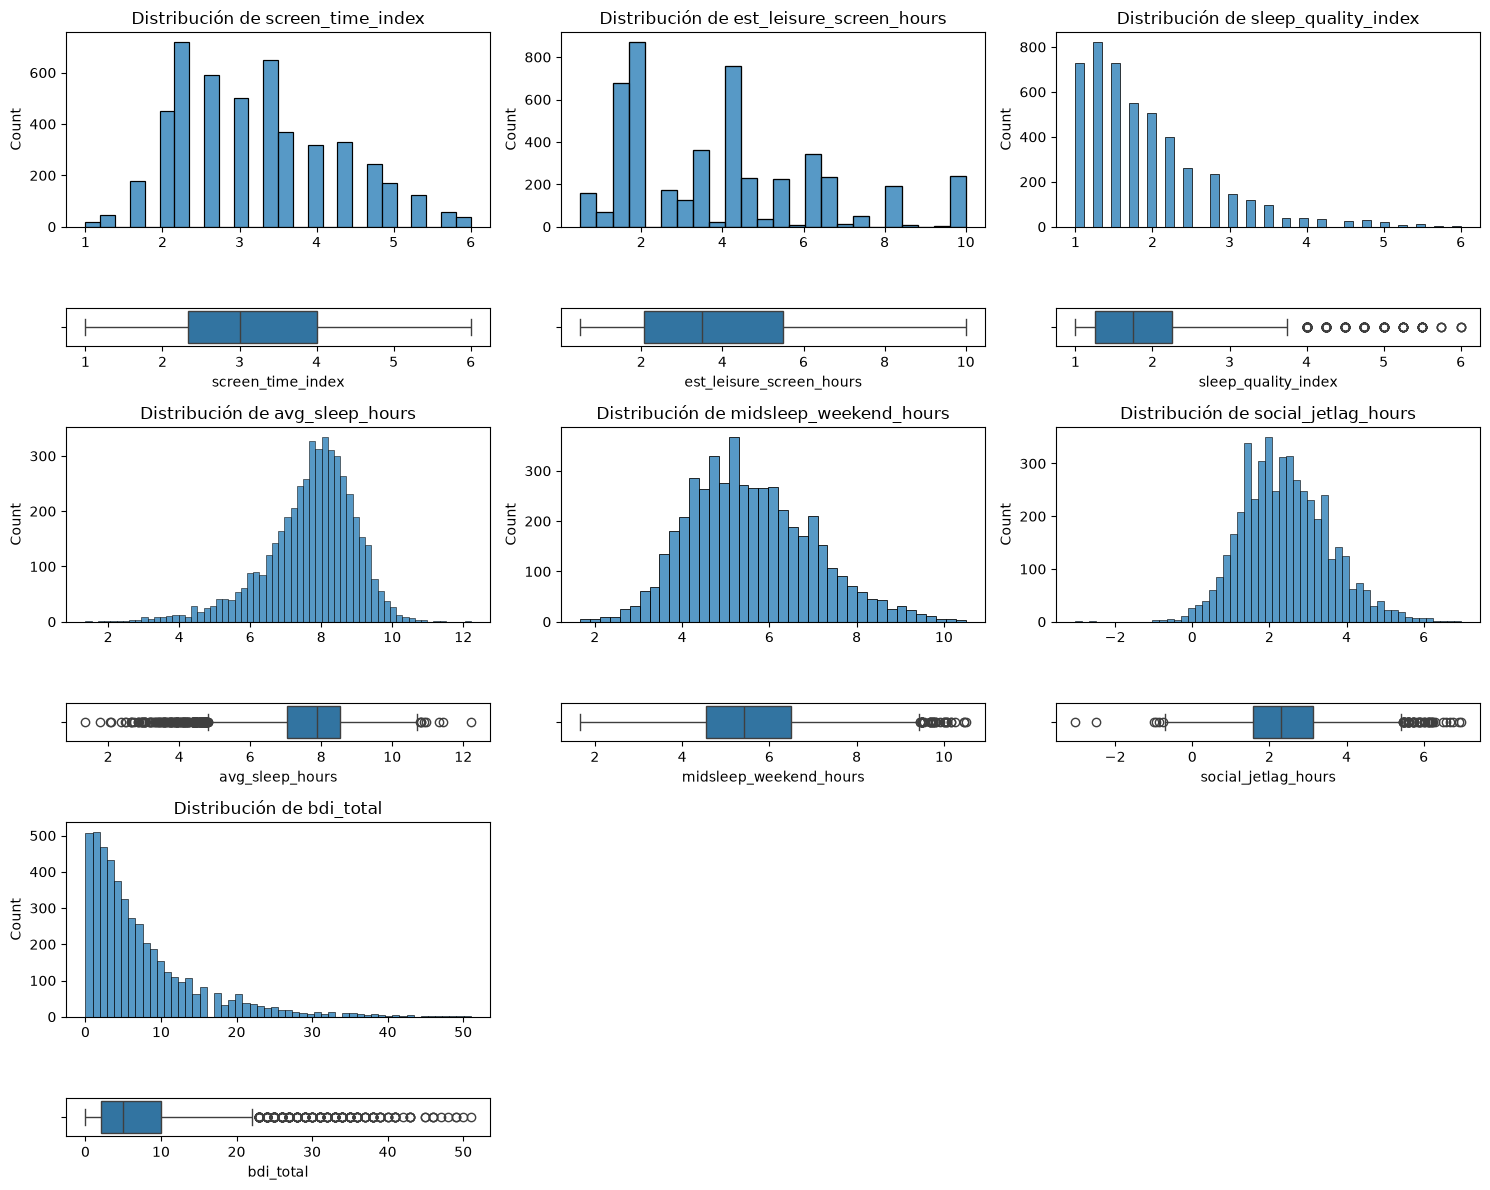

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    "screen_time_index",
    "est_leisure_screen_hours",
    "sleep_quality_index",
    "avg_sleep_hours",
    "midsleep_weekend_hours",
    "social_jetlag_hours",
    "bdi_total"
]

# 3 gráficos por fila
ncols = 3
nrows = (len(variables) + ncols - 1) // ncols

fig, axis = plt.subplots(
    nrows=2 * nrows,
    ncols=ncols,
    figsize=(15, 4 * nrows),
    gridspec_kw={"height_ratios": [5, 1] * nrows}
)

# Recorrer las variables
for i, variable in enumerate(variables):

    # Calcular fila y columna
    col = i % ncols
    row = (i // ncols) * 2

    # Histograma
    sns.histplot(
        data=df,
        x=variable,
        ax=axis[row, col]
    )

    axis[row, col].set_title(f"Distribución de {variable}")
    axis[row, col].set_xlabel("")
    
    # Boxplot
    sns.boxplot(
        data=df,
        x=variable,
        ax=axis[row + 1, col]
    )

    axis[row + 1, col].set_xlabel(variable)

# Ocultar espacios vacíos
for i in range(len(variables), nrows * ncols):
    col = i % ncols
    row = (i // ncols) * 2
    
    axis[row, col].set_visible(False)
    axis[row + 1, col].set_visible(False)

# Ajustar espacios
plt.tight_layout()

# Mostrar gráficos
plt.show()

- **screen_time_index:** presenta una distribución relativamente compacta/normal y no muestra una cantidad preocupante de valores atípicos.La distribución está bastante concentrada entre aproximadamente 2 y 4. Tiene cierta dispersión hacia valores mayores, llegando aproximadamente a 6. El boxplot no muestra una cantidad excesiva de valores atípicos. Por lo tanto, inicialmente parece una variable adecuada para utilizar como predictor en el modelo de regresión lineal.

- **est_leisure_screen_hours:** presenta una distribución multimodal, con concentraciones en determinados valores, No parece una distribución normal. Se observan concentraciones en distintos valores, especialmente alrededor de 2, 4, 6, 8 y 10 horas. Eso podría indicar que la variable está discretizada o que los datos fueron registrados en determinados intervalos. Esto no impide utilizarla como predictor en una regresión lineal, pero será necesario analizar posteriormente su relación con bdi_total para comprobar si existe una relación aproximadamente lineal. 

- **sleep_quality_index:** Esta variable presenta una distribución fuertemente asimétrica hacia la derecha. La mayoría de los valores están concentrados aproximadamente entre 1 y 3, mientras que hay algunos valores bastante mayores. Presenta una distribución asimétrica y una cantidad considerable de valores extremos. Estos valores deberán ser analizados para determinar si corresponden a observaciones válidas o a errores. No se recomienda eliminarlos automáticamente.

- **avg_sleep_hours:** Esta es una de las variables que visualmente presenta una distribución más cercana a una campana. La mayor concentración está aproximadamente alrededor de 7–9 horas.Hay personas con valores de sueño muy bajos y algunas con valores superiores a 10 horas. Sin embargo, el boxplot muestra valores extremos tanto por debajo como por encima del rango central. Presenta una distribución aproximadamente unimodal y relativamente cercana a una distribución normal, aunque existen algunos valores extremos. En principio, parece una variable adecuada para el modelo, pero los valores atípicos deberán ser revisados.

- **midsleep_weekend_hours:** Esta variable presenta una distribución bastante interesante. Tiene una concentración importante alrededor de 4–7 horas, con cierta asimetría hacia la derecha. El boxplot muestra varios valores extremos en la parte superior. Presenta una distribución relativamente continua, aunque con algunos valores extremos. Estos valores no deberían eliminarse automáticamente, ya que podrían representar horarios de sueño reales.

- **social_jetlag_hours:** La distribución tiene una forma aproximadamente unimodal, concentrándose alrededor de 1–3 horas. También presenta algunos valores negativos y valores extremos positivos. Esto tiene sentido conceptualmente porque el social jetlag representa la diferencia entre horarios de sueño y puede tomar distintos valores según cómo se haya calculado. Presenta una distribución relativamente concentrada, aunque existen valores extremos en ambos sentidos. Será necesario comprobar que dichos valores sean válidos y analizar posteriormente su relación con bdi_total.

- **bdi_total:** Esta es la variable más importante, porque es nuestra variable objetivo y. Y aquí encontramos algo que tenemos que destacar. La distribución está fuertemente sesgada hacia la derecha, hay una gran concentración de personas con valores bajos de bdi_total y cada vez menos observaciones a medida que aumenta el puntaje.
Además, el boxplot muestra numerosos valores que aparecen como outliers, llegando aproximadamente hasta 50.
Si bdi_total es un puntaje válido del instrumento utilizado, esos valores altos pueden representar personas con mayores niveles de síntomas. No son necesariamente errores.

Por lo tanto:

bdi_total presenta una distribución fuertemente asimétrica hacia la derecha y una cantidad importante de valores extremos. Debido a que estos valores representan puntajes reales del fenómeno estudiado, no deberían eliminarse automáticamente. Será necesario evaluar posteriormente su impacto sobre el modelo de regresión.






Y como ya vimos en el histograma más arriba en la parte de análisis descriptivo, la variable **'sex'** está bastante equilibrada, con una cantidad similar de observaciones en las categorías 0 y 1. Por lo tanto, no se observa un desbalance significativo que pueda afectar al modelo de regresión.

## Análisis de variables multivariante

Tras analizar las características una a una, es momento de analizarlas en relación con la predictora y con ellas mismas, para sacar conclusiones más claras acerca de sus relaciones y poder tomar decisiones sobre su procesamiento.

### Análisis numérico-numérico


Para comparar dos columnas numéricas se utilizan diagramas de dispersión y análisis de correlaciones.

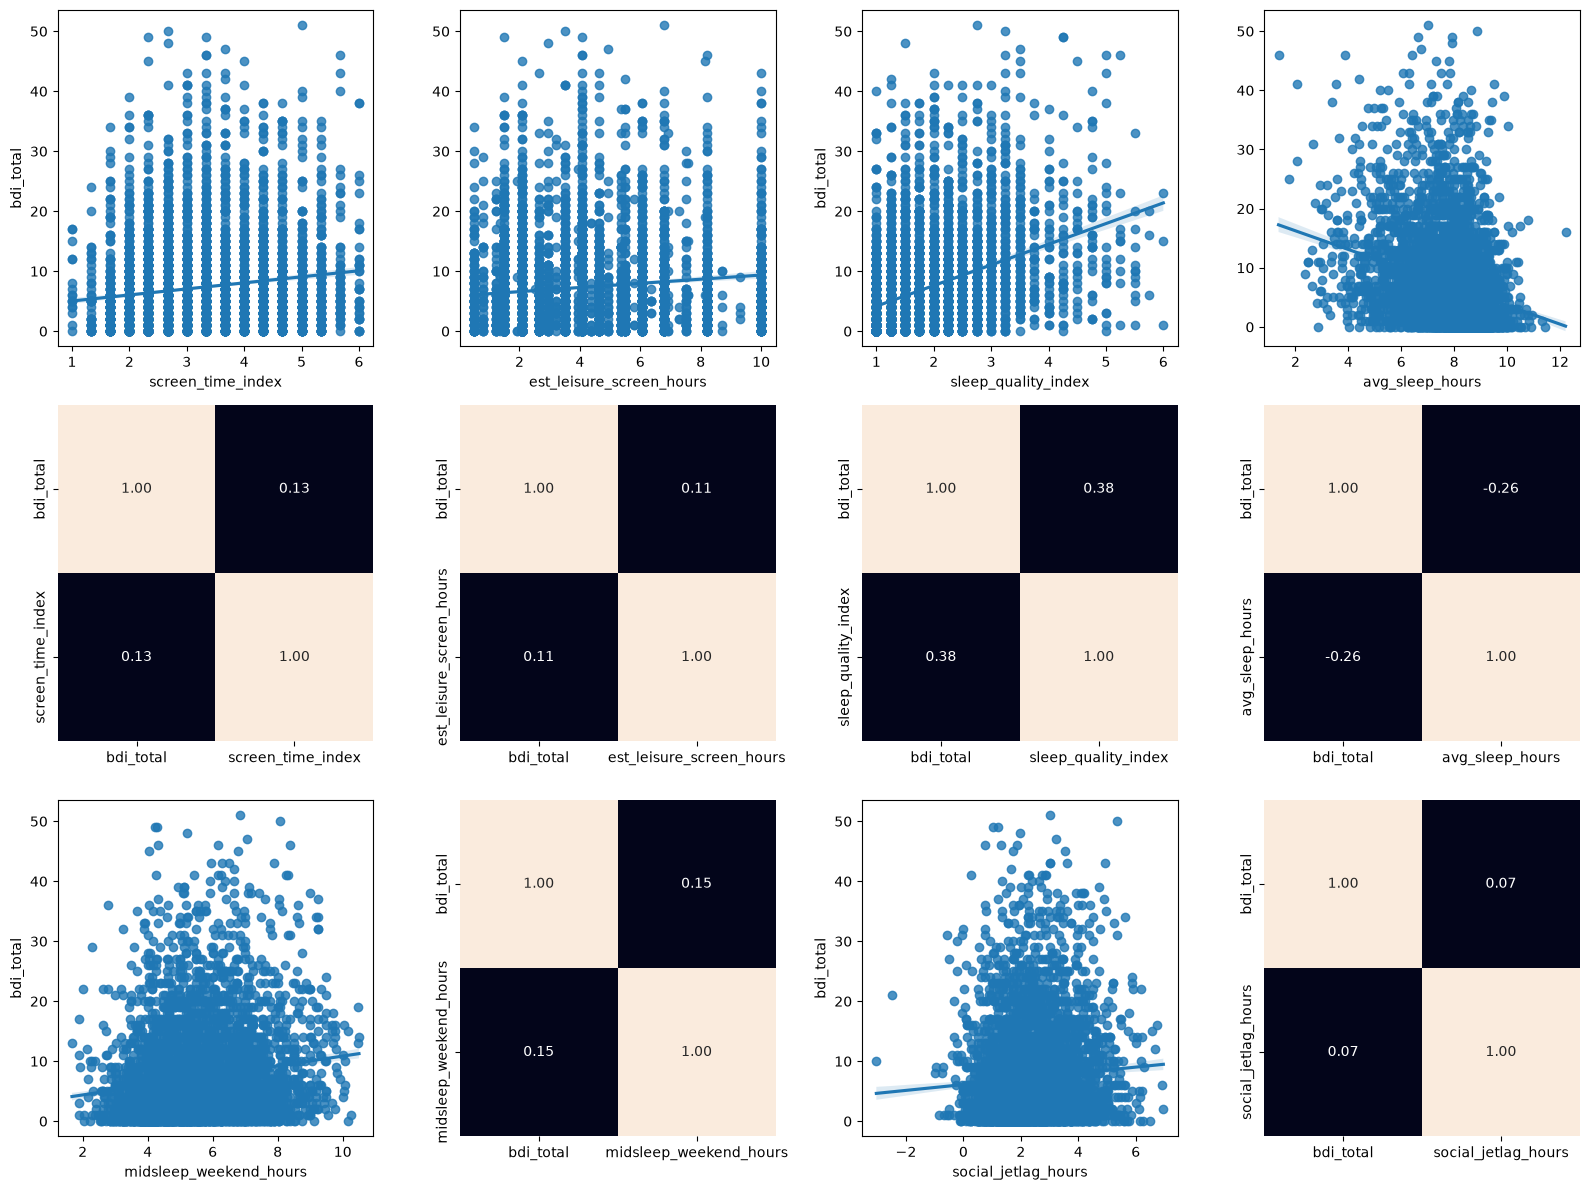

In [46]:
fig, axis = plt.subplots(3, 4, figsize=(16, 12))

# screen_time_index
sns.regplot(
    ax=axis[0, 0],
    data=df,
    x="screen_time_index",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "screen_time_index"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 0],
    cbar=False
)

# est_leisure_screen_hours
sns.regplot(
    ax=axis[0, 1],
    data=df,
    x="est_leisure_screen_hours",
    y="bdi_total"
).set(ylabel=None)

sns.heatmap(
    df[["bdi_total", "est_leisure_screen_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 1],
    cbar=False
)

# sleep_quality_index
sns.regplot(
    ax=axis[0, 2],
    data=df,
    x="sleep_quality_index",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "sleep_quality_index"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 2],
    cbar=False
)

# avg_sleep_hours
sns.regplot(
    ax=axis[0, 3],
    data=df,
    x="avg_sleep_hours",
    y="bdi_total"
).set(ylabel=None)

sns.heatmap(
    df[["bdi_total", "avg_sleep_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 3],
    cbar=False
)

# midsleep_weekend_hours
sns.regplot(
    ax=axis[2, 0],
    data=df,
    x="midsleep_weekend_hours",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "midsleep_weekend_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[2, 1],
    cbar=False
)

# social_jetlag_hours
sns.regplot(
    ax=axis[2, 2],
    data=df,
    x="social_jetlag_hours",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "social_jetlag_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[2, 3],
    cbar=False
)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Los diagramas de correlación permiten identificar la dirección y la intensidad de la relación lineal entre las variables predictoras y el nivel de síntomas depresivos (bdi_total). Estas correlaciones sirven como análisis exploratorio previo al modelo de regresión, permitiendo detectar variables potencialmente relevantes y posibles problemas de multicolinealidad entre las predictoras.
 
Los diagramas de dispersión y las matrices de correlación muestran que ninguna de las variables predictoras presenta una relación lineal fuerte con bdi_total. La mayor asociación corresponde a sleep_quality_index (r = 0.38), seguida de avg_sleep_hours (r = -0.26). Las variables relacionadas con el uso de pantallas presentan correlaciones débiles (screen_time_index = 0.13; est_leisure_screen_hours = 0.11), mientras que social_jetlag_hours muestra una asociación prácticamente nula (r = 0.07). Estos resultados sugieren que las variables podrían aportar información al modelo de regresión de manera conjunta, aunque ninguna parece explicar por sí sola una proporción elevada de la variabilidad de los síntomas depresivos.


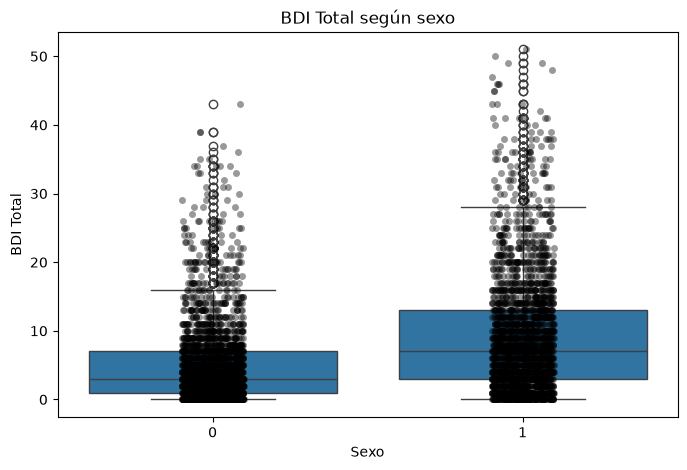

In [47]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="sex", y="bdi_total")
sns.stripplot(data=df, x="sex", y="bdi_total", color="black", alpha=0.4)

plt.title("BDI Total según sexo")
plt.xlabel("Sexo")
plt.ylabel("BDI Total")

plt.show()

Este diseño de boxplot nos permite mostrar los puntos individuales para ver mejor la distribución.

Se observa una diferencia en la distribución de bdi_total según el sexo. El grupo 0 (Girl) presenta una mediana de BDI Total más alta que el grupo 1 (Boy), aproximadamente 7 frente a 3 puntos.
Además, el grupo 0 muestra mayor dispersión, con valores de BDI más elevados y un rango intercuartílico más amplio.

Ambos grupos presentan numerosos valores atípicos altos, lo que indica que existen participantes con niveles de síntomas depresivos considerablemente superiores al resto.

El grupo 0 alcanza valores atípicos de BDI de aproximadamente 50 puntos, mientras que el grupo 1 llega hasta alrededor de 43.
Por lo tanto, sex podría ser una variable relevante para explicar bdi_total en el modelo de regresión, aunque sería necesario realizar un análisis estadístico para determinar si la diferencia observada es significativa.

**Conclusión: El boxplot muestra que existen diferencias en los niveles de bdi_total entre ambos grupos de sexo. El grupo 0 presenta una mediana y una variabilidad mayores, además de valores extremos más elevados. Esto sugiere que el sexo podría estar asociado con los síntomas depresivos y ser una variable potencialmente relevante para el modelo de regresión.**